# 🧪 TinyML Lab 9 — Training Gesture Classifiers with Differential Privacy

Welcome to **Lab 9** of the TinyML course! In this lab, you will:

- ✅ Preprocess real-world accelerometer and gyroscope data for gesture classification.
- ✅ Train a deep neural network using **Differentially Private SGD (DP-SGD)**.
- ✅ Export your model to **TensorFlow Lite** for embedded deployment.
- ✅ Convert your `.tflite` model to a `.h` header file for use on microcontrollers.

---

### 🎯 Learning Objectives

By the end of this lab, you will be able to:

- Understand the intuition behind **differential privacy** and why it's crucial for on-device ML.
- Use `tensorflow_privacy` to train a model with quantifiable privacy guarantees.
- Convert a trained model into **TFLite format** and a **C header file** for deployment on MCUs like the Arduino Nano BLE Sense.
- Analyze training curves to evaluate privacy-utility tradeoffs.

---

### 📂 Dataset

We revisit the **gesture recognition dataset** used in Lab 8, consisting of time-series sensor data for gestures like `"hi"` and `"sup"`. Each recording contains 119 samples of:
- Accelerometer: `aX`, `aY`, `aZ`
- Gyroscope: `gX`, `gY`, `gZ`

---

### 🔒 Why Differential Privacy in TinyML?

TinyML applications often involve **sensitive user data** collected from personal or wearable devices. Training models with **differential privacy** helps ensure that:

- No single user’s data point can be reverse-engineered from the model.
- Models generalize better under data constraints.

We’ll be using **Google’s `tensorflow_privacy` library** to implement this safely and efficiently.

---

Before we begin, make sure that the dataset files from lab 8 (`hi.csv` and `sup.csv`) are present in the working directory. We strongly recommend you to run this lab in a separate virtual environment if you're running this lab on your own computer.

Next, we install the dependencies required for this lab:

In [2]:
# Note: Remember to remove Tensorflow packages if you are running this lab notebook in Google Colab!

# Install dependencies for this lab, including `tensorflow`, `tensorflow-privacy` and other packages
!pip uninstall -y tensorflow tensorflow-privacy tensorflow-estimator numpy pandas
%pip install 'tensorflow==2.15' tensorflow-privacy tensorflow-probability pandas matplotlib

Found existing installation: tensorflow 2.15.0
Uninstalling tensorflow-2.15.0:
  Successfully uninstalled tensorflow-2.15.0
Found existing installation: tensorflow_privacy 0.9.0
Uninstalling tensorflow_privacy-0.9.0:
  Successfully uninstalled tensorflow_privacy-0.9.0
Found existing installation: tensorflow-estimator 2.15.0
Uninstalling tensorflow-estimator-2.15.0:
  Successfully uninstalled tensorflow-estimator-2.15.0
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: pandas 3.0.3
Uninstalling pandas-3.0.3:
  Successfully uninstalled pandas-3.0.3
  Using cached tensorflow-2.15.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.4 kB)
  Using cached tensorflow_privacy-0.9.0-py3-none-any.whl.metadata (763 bytes)
  Using cached pandas-3.0.3-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.many

As a test, we will try to import `tensorflow_privacy` in our notebook:

In [1]:
import tensorflow_privacy

# If the import was successful, this line will be printed
print("`tensorflow_privacy` imported successfully")

`tensorflow_privacy` imported successfully


### 🔒 Training a Differentially Private Model on Gesture Data

This script prepares gesture recognition data, builds a neural network, and trains it using **Differentially Private SGD (DP-SGD)** via `tensorflow_privacy`.

#### 📋 Key Highlights

- **Backend Configuration**:
  We set the `Agg` backend for `matplotlib` to enable headless plotting in non-GUI environments.

- **Reproducibility**:
  Fixed random seeds ensure the same results across runs.

- **Data Loading**:
  Each `.csv` file corresponds to a gesture (e.g., `"hi.csv"`, `"sup.csv"`). For each gesture:
  - Accelerometer and gyroscope values are normalized.
  - One-hot vectors are generated as output labels.
  - Data is reshaped and split into train/validation/test sets.

- **DP Optimizer**:
  ```python
  tensorflow_privacy.DPKerasSGDOptimizer(
      l2_norm_clip=1.0,
      noise_multiplier=0.7,
      num_microbatches=10,
      learning_rate=0.05
  )
  ```
  - Adds Gaussian noise to gradients.
  - Clips per-example gradients to a norm of 1.0.
  - Applies DP-SGD with mini-batch training.

- **Model Architecture**:
  A simple fully connected neural network:
  - Dense(50) → ReLU  
  - Dense(15) → ReLU  
  - Dense(output) → Softmax (multi-class classification)

- **Training**:
  500 epochs using the DP optimizer and categorical crossentropy loss.

- **Evaluation & Export**:
  - Loss and accuracy trends are plotted.
  - Final accuracy is printed.
  - Trained model is converted to TFLite format for deployment.
  - `.tflite` file is converted to a C array in `model.h`.

#### 💡 Dataset

This is the same **American Sign Language (ASL)** gesture dataset used in Lab 8, now trained with DP to protect individual recordings from reverse inference.

> ⚠️ Ensure the CSV files (`hi.csv`, `sup.csv`, ...) are present in the same directory before running this script.


In [2]:
import tensorflow as tf
import tensorflow_privacy
from tensorflow_privacy.privacy.optimizers import dp_optimizer_keras
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

# Make sure that you're using Tensorflow 2.15, as any higher version would not work due to dependency version mismatch!
print(f"TensorFlow version = {tf.__version__}\n")

# Set a fixed random seed value, for reproducibility, this will allow us to get
# the same random numbers each time the notebook is run
# "Reproducibility" means the ability to run the same thing twice and get
# the same results.

SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version = 2.15.0



## Load and Parse Gesture Data

This cell reads the gesture CSV files and prepares the data for training. Each gesture file is parsed, normalized (accelerometer: -4 to +4 → 0 to 1, gyroscope: -2000 to +2000 → 0 to 1), and converted into input tensors and one-hot encoded labels.

In [3]:
# the list of gestures that data is available for
GESTURES = [
    "hi",
    "sup",
]

SAMPLES_PER_GESTURE = 119

NUM_GESTURES = len(GESTURES)

# create a one-hot encoded matrix that is used in the output
ONE_HOT_ENCODED_GESTURES = np.eye(NUM_GESTURES)

inputs = []
outputs = []

# read each csv file and push an input and output
for gesture_index in range(NUM_GESTURES):
  gesture = GESTURES[gesture_index]
  print(f"Processing index {gesture_index} for gesture '{gesture}'.")

  output = ONE_HOT_ENCODED_GESTURES[gesture_index]

  df = pd.read_csv(gesture + ".csv")

  # calculate the number of gesture recordings in the file
  num_recordings = int(df.shape[0] / SAMPLES_PER_GESTURE)

  print(f"\tThere are {num_recordings} recordings of the {gesture} gesture.")

  for i in range(num_recordings):
    tensor = []
    for j in range(SAMPLES_PER_GESTURE):
      index = i * SAMPLES_PER_GESTURE + j
      # normalize the input data, between 0 to 1:
      # - acceleration is between: -4 to +4
      # - gyroscope is between: -2000 to +2000
      tensor += [
          (df['aX'][index] + 4) / 8,
          (df['aY'][index] + 4) / 8,
          (df['aZ'][index] + 4) / 8,
          (df['gX'][index] + 2000) / 4000,
          (df['gY'][index] + 2000) / 4000,
          (df['gZ'][index] + 2000) / 4000
      ]

    inputs.append(tensor)
    outputs.append(output)

# convert the list to numpy array
inputs = np.array(inputs)
outputs = np.array(outputs)

print("Data set parsing and preparation complete.")

Processing index 0 for gesture 'hi'.
	There are 50 recordings of the hi gesture.
Processing index 1 for gesture 'sup'.
	There are 50 recordings of the sup gesture.
Data set parsing and preparation complete.


## Randomize and Split Data

Shuffle the data randomly and split it into training (60%), validation (20%), and test (20%) sets. Then wrap them in `tf.data.Dataset` with batching for efficient training.

In [4]:
# Randomize the order of the inputs, so they can be evenly distributed for training, testing, and validation
# https://stackoverflow.com/a/37710486/2020087
num_inputs = len(inputs)
randomize = np.arange(num_inputs)
np.random.shuffle(randomize)

# Swap the consecutive indexes (0, 1, 2, etc) with the randomized indexes
inputs = inputs[randomize]
outputs = outputs[randomize]

# Split the recordings (group of samples) into three sets: training, testing and validation
TRAIN_SPLIT = int(0.6 * num_inputs)
TEST_SPLIT = int(0.2 * num_inputs + TRAIN_SPLIT)

print('----------------------------------------------------------------------')
print('Dataset Info:')
print('----------------------------------------------------------------------')
print('Total Number of Training Data: ' + str(TRAIN_SPLIT))
print('Total Number of Test Data: ' + str(TEST_SPLIT - TRAIN_SPLIT))
print('Total Number of Validation Data: ' + str(num_inputs - TEST_SPLIT))
print('----------------------------------------------------------------------')

inputs_train, inputs_test, inputs_validate = np.split(inputs, [TRAIN_SPLIT, TEST_SPLIT])
outputs_train, outputs_test, outputs_validate = np.split(outputs, [TRAIN_SPLIT, TEST_SPLIT])

# Wrap training and validation data in tf.data.Dataset with drop_remainder=True
train_dataset = tf.data.Dataset.from_tensor_slices((inputs_train, outputs_train))
train_dataset = train_dataset.shuffle(buffer_size=60).batch(10, drop_remainder=True)

val_dataset = tf.data.Dataset.from_tensor_slices((inputs_validate, outputs_validate))
val_dataset = val_dataset.batch(10, drop_remainder=True)

print("Data set randomization and splitting complete.")

----------------------------------------------------------------------
Dataset Info:
----------------------------------------------------------------------
Total Number of Training Data: 60
Total Number of Test Data: 20
Total Number of Validation Data: 20
----------------------------------------------------------------------
Data set randomization and splitting complete.


## Build Model with Differential Privacy

Create a Keras sequential model with two hidden dense layers (50 and 15 units) and a softmax output layer. Configure the model with a differentially private SGD optimizer and categorical crossentropy loss.

In [5]:
# differentially private optimizer
optimizer = tensorflow_privacy.DPKerasSGDOptimizer(
    l2_norm_clip=1.0,
    noise_multiplier=0.7,
    num_microbatches=10,
    learning_rate=0.05
)

# build the model and train it
model = tf.keras.Sequential([
    tf.keras.layers.Dense(50, activation='relu'), # Use ReLU for performance
    tf.keras.layers.Dense(15, activation='relu'),
    tf.keras.layers.Dense(NUM_GESTURES, activation='softmax')
])

loss_fn = tf.keras.losses.CategoricalCrossentropy(
    # We have already applied softmax in the last layer of the model
    from_logits=False,
    reduction=tf.keras.losses.Reduction.NONE
)

model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

## Train Model

Train the model for 500 epochs using the differentially private optimizer on the training dataset, with validation on the validation dataset.

In [6]:
# Train the model using dataset API
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=500
)

Epoch 1/500
6/6 [==============================] - 1s 30ms/step - loss: 0.7572 - accuracy: 0.4500 - val_loss: 0.6691 - val_accuracy: 0.7000
Epoch 2/500
6/6 [==============================] - 0s 5ms/step - loss: 0.6812 - accuracy: 0.5167 - val_loss: 0.6898 - val_accuracy: 0.4000
Epoch 3/500
6/6 [==============================] - 0s 5ms/step - loss: 0.6804 - accuracy: 0.5500 - val_loss: 0.7743 - val_accuracy: 0.4000
Epoch 4/500
6/6 [==============================] - 0s 5ms/step - loss: 0.7881 - accuracy: 0.5500 - val_loss: 0.8987 - val_accuracy: 0.4000
Epoch 5/500
6/6 [==============================] - 0s 6ms/step - loss: 0.7366 - accuracy: 0.5500 - val_loss: 0.9215 - val_accuracy: 0.4000
Epoch 6/500
6/6 [==============================] - 0s 5ms/step - loss: 0.8243 - accuracy: 0.5500 - val_loss: 1.0946 - val_accuracy: 0.4000
Epoch 7/500
6/6 [==============================] - 0s 5ms/step - loss: 0.9188 - accuracy: 0.5500 - val_loss: 1.3378 - val_accuracy: 0.4000
Epoch 8/500
6/6 [=========

## Evaluate Model Performance

Plot the training and validation loss over epochs to visualize convergence.

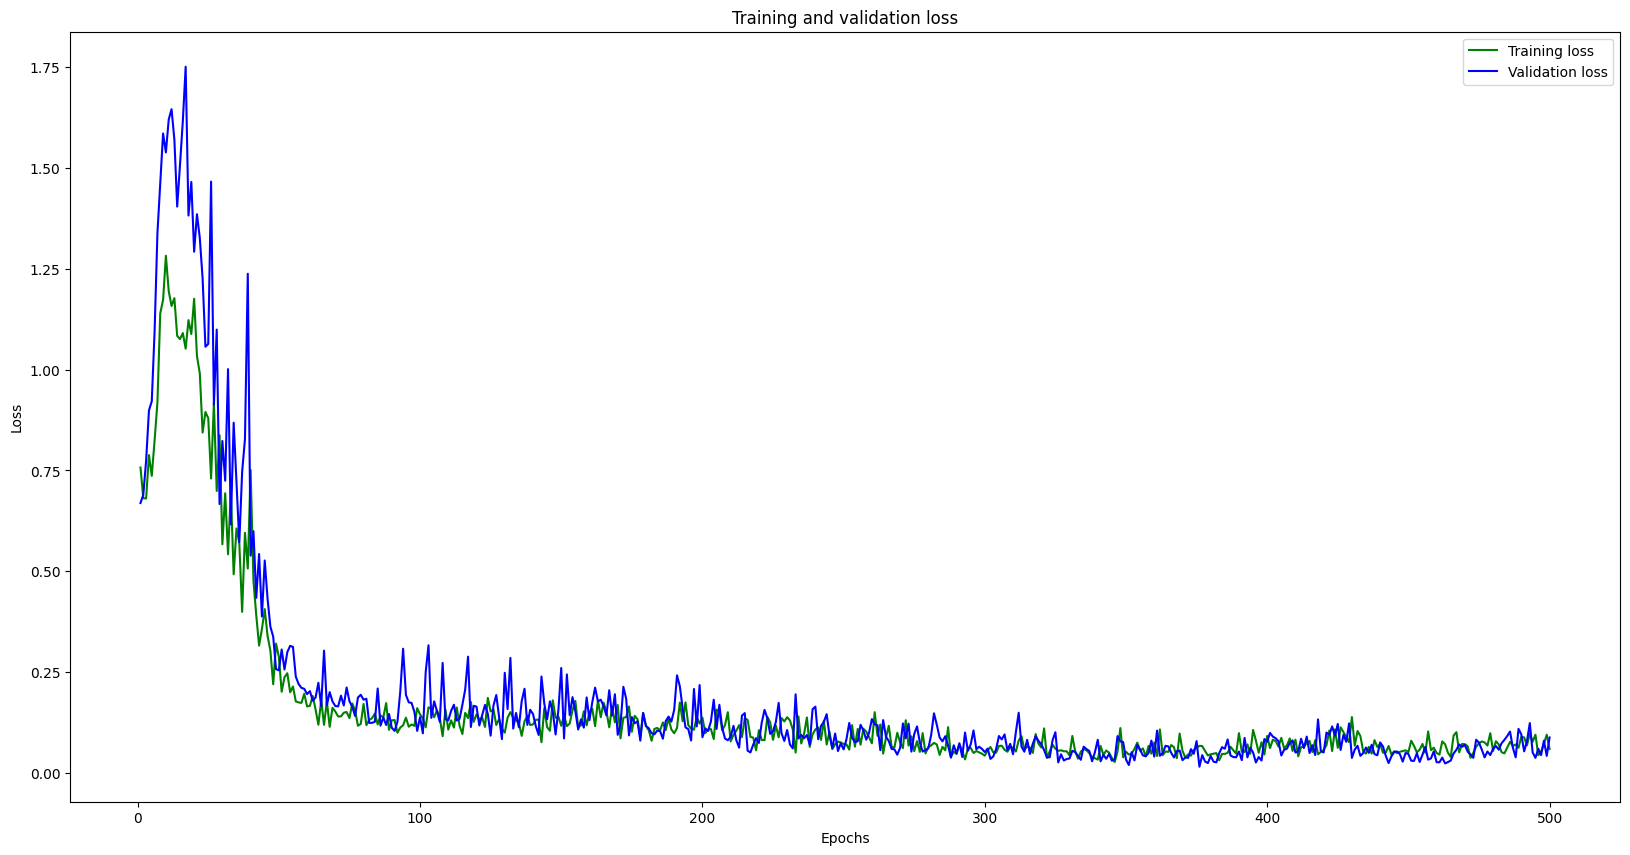

In [7]:
# increase the size of the graphs. The default size is (6,4).
plt.rcParams["figure.figsize"] = (20, 10)

# graph the loss, the model above is configure to use "mean squared error" as the loss function
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'g', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.savefig('training_loss_plot.png')
plt.show()

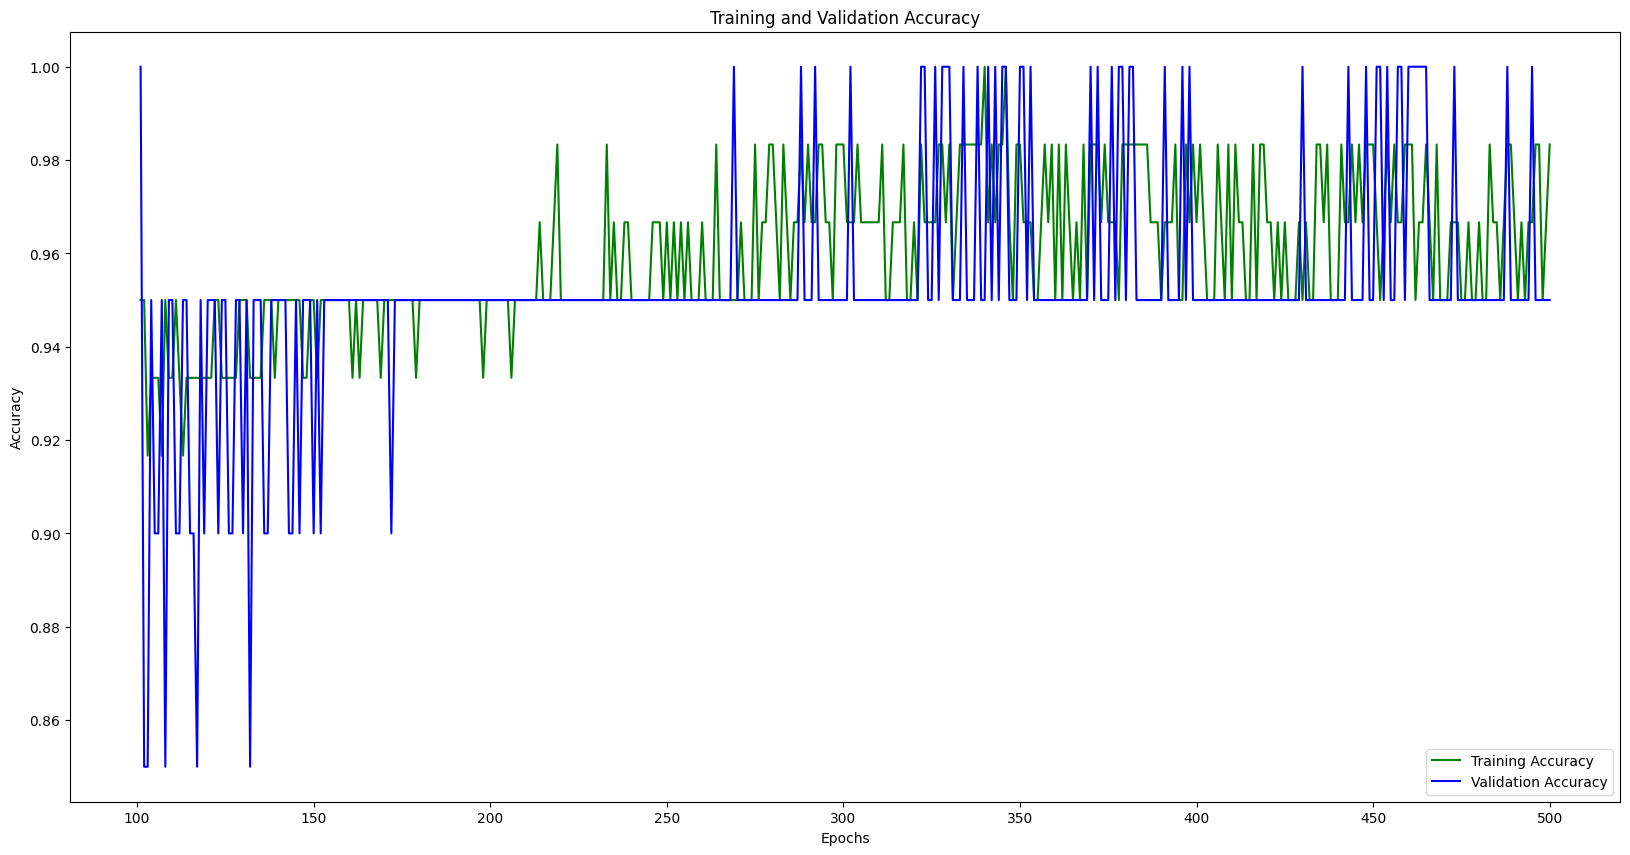

In [8]:
SKIP = 100
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc) + 1)

plt.figure()
plt.plot(epochs[SKIP:], acc[SKIP:], 'g', label='Training Accuracy')
plt.plot(epochs[SKIP:], val_acc[SKIP:], 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig('training_accuracy_plot.png')
plt.show()

In [9]:
# use the model to predict the test inputs
predictions = model.predict(inputs_test)

predictions = tf.cast(predictions, tf.float32)
outputs_test = tf.cast(outputs_test, tf.float32)

# Compute predictions
predicted_classes = tf.argmax(predictions, axis=1)
actual_classes = tf.argmax(outputs_test, axis=1)

# Compute the accuracy
accuracy = tf.reduce_mean(tf.cast(tf.equal(predicted_classes, actual_classes), tf.float32))

# Print the accuracy
print("Accuracy = ", accuracy.numpy())

1/1 [==============================] - 0s 84ms/step
Accuracy =  0.9


## Export to TensorFlow Lite

Convert the trained Keras model to TensorFlow Lite format for efficient inference on edge devices.

In [10]:
import os

# Convert model to TFLite format without quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the TFLite model
with open("gesture_model.tflite", "wb") as f:
    f.write(tflite_model)

basic_model_size = os.path.getsize("gesture_model.tflite")
print(f"Model is {basic_model_size} bytes")

Model is 148468 bytes


## Convert to C Header File

Convert the `.tflite` model to a C-style header file (`model.h`) containing the model as a byte array, ready for embedded deployment on microcontrollers.

In [11]:
# Convert .tflite model to a C-style array in a header file
# Using subprocess instead of shell magic
import subprocess

# Use xxd -i to generate C array (requires xxd installed)
subprocess.run("xxd -i gesture_model.tflite > model.h", shell=True)

# Print size of the header file
model_h_size = os.path.getsize("model.h")
print(f"Header file, model.h, is {model_h_size:,} bytes.")
print("You can now use model.h in your embedded deployment.")

Header file, model.h, is 915,645 bytes.
You can now use model.h in your embedded deployment.


## Summary

The training pipeline is now complete! The code above:

- ✅ Loads and normalizes accelerometer + gyroscope features from gesture CSV files
- ✅ Trains a Keras model with `DPKerasSGDOptimizer` for privacy-preserving learning
- ✅ Evaluates model accuracy on test data with diagnostic plots
- ✅ Converts the trained model to `.tflite` format for efficient inference
- ✅ Creates a C-style header file `model.h` for embedded deployment on microcontrollers like Arduino Nano BLE Sense

**Output Files Generated:**
- `gesture_model.tflite`: Compressed ML model for deployment
- `model.h`: C header file containing the model as a byte array
- `training_loss_plot.png`, `training_accuracy_plot.png`: Diagnostic plots showing convergence